# EDA — MOT17 (détection/tracking) et Market-1501 (ré-identification)

## Présentation des datasets

Le projet vise à **suivre des individus dans une vidéo**, y compris après une occlusion ou une
sortie de champ temporaire. Ça demande deux capacités différentes, donc deux données
d'entraînement différentes :

| | MOT17 | Market-1501 |
|---|---|---|
| **Sert à entraîner** | le détecteur (YOLOv8) + évaluer le tracker | l'encoder de ré-identification |
| **Répond à la question** | où sont les objets dans cette frame ? | cette personne recadrée est-elle la même que celle vue plus tôt ? |
| **Nature des données** | séquences vidéo continues, annotées frame par frame | images fixes recadrées, regroupées par identité |
| **Dans le pipeline final** | détection, tracking court terme | ré-association après occlusion/disparition |

**Pourquoi un seul dataset ne suffit pas** : MOT17 permet d'entraîner un tracker qui suit un objet
tant qu'il reste visible frame après frame. Mais dès qu'un piéton disparaît plus de quelques frames, le tracker perd son identifiant et lui en attribue un nouveau. Market-1501 sert précisément à apprendre une représentation visuelle qui reste stable pour une même personne même vue sous un angle de caméra différent, pour pouvoir la reconnaître et réattribuer le bon identifiant après une interruption.

**Objectif final concret** : à partir d'une vidéo, produire des trajectoires continues et
correctement identifiées d'un bout à l'autre, même en cas d'occlusion

In [28]:
import sys
sys.path.append('..')

import re
import configparser

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

from src.config import MOT17_DIR, MARKET1501_DIR

print(f'MOT17 dir: {MOT17_DIR} (existe: {MOT17_DIR.exists()})')
print(f'Market-1501 dir: {MARKET1501_DIR} (existe: {MARKET1501_DIR.exists()})')

MOT17 dir: C:\Users\baptm\Downloads\mot-reid-pipeline\data\raw\MOT17 (existe: True)
Market-1501 dir: C:\Users\baptm\Downloads\mot-reid-pipeline\data\raw\Market-1501 (existe: True)


## 1. Structure du dataset MOT17

Format attendu par séquence : `img1/` (frames) + `gt/gt.txt` (annotations) + `seqinfo.ini` (métadonnées).
Colonnes de `gt.txt` : `frame, id, bb_left, bb_top, bb_width, bb_height, conf, class, visibility`

In [ ]:
sequences = sorted(MOT17_DIR.glob('train/*'))
print(f'{len(sequences)} séquences trouvées')
for seq in sequences:
    print(seq.name)

21 sequences trouvees
MOT17-02-DPM
MOT17-02-FRCNN
MOT17-02-SDP
MOT17-04-DPM
MOT17-04-FRCNN
MOT17-04-SDP
MOT17-05-DPM
MOT17-05-FRCNN
MOT17-05-SDP
MOT17-09-DPM
MOT17-09-FRCNN
MOT17-09-SDP
MOT17-10-DPM
MOT17-10-FRCNN
MOT17-10-SDP
MOT17-11-DPM
MOT17-11-FRCNN
MOT17-11-SDP
MOT17-13-DPM
MOT17-13-FRCNN
MOT17-13-SDP


### Séquences dupliquées

MOT17 fournit **3 jeux de détections publiques différentes (DPM, FRCNN, SDP) pour les mêmes
vidéos**. `MOT17-02-DPM`, `MOT17-02-FRCNN` et `MOT17-02-SDP` sont donc la **même vidéo**, avec
la même vérité terrain (`gt.txt` identique), seule la colonne de détections publiques change.

**Conséquence** : un split train/val naïf (ex: `MOT17-02-DPM` en train, `MOT17-02-SDP` en val) permettrait des fuites de données. Le split devra se faire par **vidéo de base**, pas par variante.

In [51]:
base_names = sorted({re.match(r'(MOT17-\d+)', s.name).group(1) for s in sequences})
print(f'{len(sequences)} dossiers de séquences, mais seulement {len(base_names)} vidéos uniques :')
for b in base_names:
    variants = [s.name for s in sequences if s.name.startswith(b + '-')]
    print(f'  {b}: {variants}')

21 dossiers de séquences, mais seulement 7 vidéos uniques :
  MOT17-02: ['MOT17-02-DPM', 'MOT17-02-FRCNN', 'MOT17-02-SDP']
  MOT17-04: ['MOT17-04-DPM', 'MOT17-04-FRCNN', 'MOT17-04-SDP']
  MOT17-05: ['MOT17-05-DPM', 'MOT17-05-FRCNN', 'MOT17-05-SDP']
  MOT17-09: ['MOT17-09-DPM', 'MOT17-09-FRCNN', 'MOT17-09-SDP']
  MOT17-10: ['MOT17-10-DPM', 'MOT17-10-FRCNN', 'MOT17-10-SDP']
  MOT17-11: ['MOT17-11-DPM', 'MOT17-11-FRCNN', 'MOT17-11-SDP']
  MOT17-13: ['MOT17-13-DPM', 'MOT17-13-FRCNN', 'MOT17-13-SDP']


In [31]:
# Verification : le gt.txt est-il bien identique entre les 3 variantes d'une meme video ?
import filecmp
sample_base = base_names[0]
variant_paths = [s for s in sequences if s.name.startswith(sample_base + '-')]
gt_files = [v / 'gt' / 'gt.txt' for v in variant_paths]
all_identical = all(filecmp.cmp(gt_files[0], g, shallow=False) for g in gt_files[1:])
print(f'gt.txt identiques entre variantes de {sample_base} : {all_identical}')

gt.txt identiques entre variantes de MOT17-02 : True


### Métadonnées des séquences (résolution, framerate)

Chaque séquence a des caractéristiques différentes (résolution, fps) — important pour la
normalisation et pour choisir une taille d'entrée cohérente pour le détecteur.

In [32]:
def read_seqinfo(seq_path):
    cfg = configparser.ConfigParser()
    cfg.read(seq_path / 'seqinfo.ini')
    s = cfg['Sequence']
    return {
        'name': s.get('name'),
        'imWidth': int(s.get('imWidth')),
        'imHeight': int(s.get('imHeight')),
        'frameRate': int(s.get('frameRate')),
        'seqLength': int(s.get('seqLength')),
    }

seqinfo_df = pd.DataFrame([read_seqinfo(s) for s in sequences if s.name.startswith(tuple(base_names))])
seqinfo_df = seqinfo_df.drop_duplicates(subset=['imWidth', 'imHeight', 'frameRate', 'seqLength']).reset_index(drop=True)
seqinfo_df

,name,imWidth,imHeight,frameRate,seqLength
0,MOT17-02-DPM,1920,1080,30,600
1,MOT17-04-DPM,1920,1080,30,1050
2,MOT17-05-DPM,640,480,14,837
3,MOT17-09-DPM,1920,1080,30,525
4,MOT17-10-DPM,1920,1080,30,654
5,MOT17-11-DPM,1920,1080,30,900
6,MOT17-13-DPM,1920,1080,25,750


### Charger l'ensemble des séquences

In [ ]:
gt_cols = ['frame', 'id', 'bb_left', 'bb_top', 'bb_width', 'bb_height', 'conf', 'class', 'visibility']

def load_gt(base_name):
    # une seule variante suffit puisque gt.txt est identique entre variantes
    seq_path = next(s for s in sequences if s.name.startswith(base_name + '-'))
    df = pd.read_csv(seq_path / 'gt' / 'gt.txt', names=gt_cols)
    df['sequence'] = base_name
    return df

df_all = pd.concat([load_gt(b) for b in base_names], ignore_index=True)
print(f'{len(df_all)} annotations chargees sur {df_all.sequence.nunique()} séquences')
df_all.describe()

204701 annotations chargees sur 7 sequences


,frame,id,bb_left,bb_top,bb_width,bb_height,conf,class,visibility
count,204701.000000,204701.000000,204701.000000,204701.000000,204701.000000,204701.000000,204701.000000,204701.000000,204701.000000
mean,430.196560,52.052095,887.151592,341.374068,77.737305,166.007030,0.548590,4.243697,0.627955
std,280.189171,38.115012,507.092221,245.360734,81.349862,143.088731,0.497635,4.078068,0.366736
min,1.000000,1.000000,-479.000000,-269.000000,7.000000,13.000000,0.000000,1.000000,0.000000
25%,198.000000,23.000000,514.000000,129.000000,34.000000,85.000000,0.000000,1.000000,0.293110
50%,392.000000,45.000000,781.000000,363.000000,53.000000,127.000000,1.000000,1.000000,0.729560
75%,623.000000,75.000000,1300.000000,493.000000,91.000000,188.000000,1.000000,9.000000,1.000000
max,1050.000000,188.000000,1922.000000,1069.000000,975.000000,1620.000000,1.000000,12.000000,1.000000


## 2. Distribution du nombre d'objets par frame

Utile pour anticiper la difficulté du tracking (foules denses = plus d'occlusions).

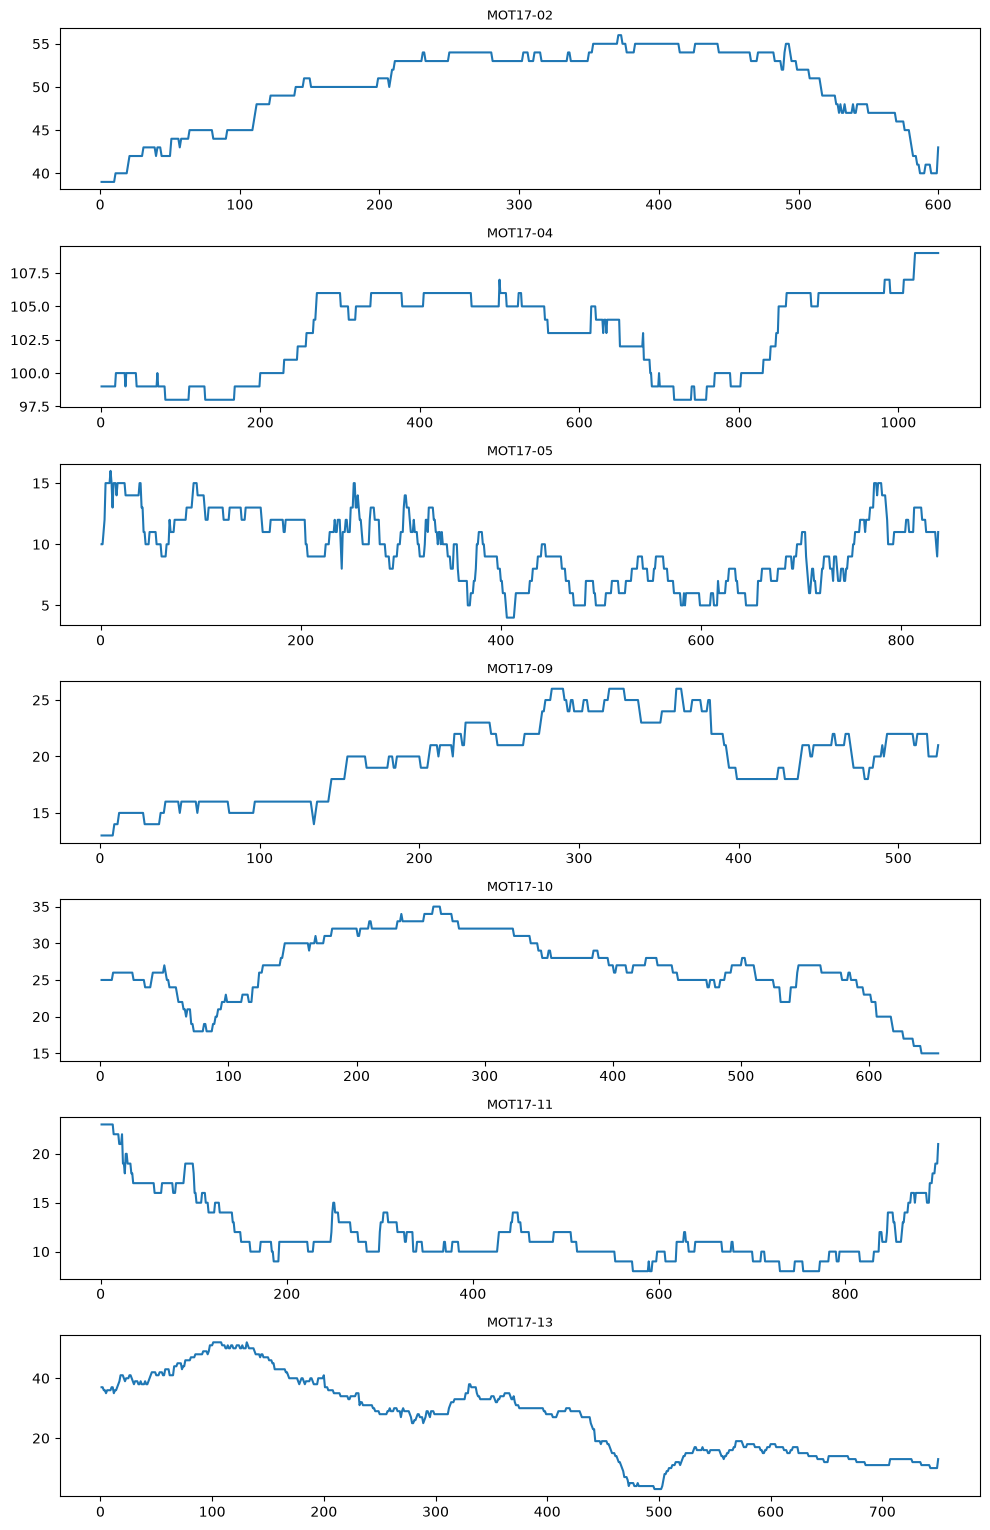

In [34]:
fig, axes = plt.subplots(len(base_names), 1, figsize=(10, 2.2 * len(base_names)), sharex=False)
for ax, b in zip(axes, base_names):
    seq_df = df_all[df_all.sequence == b]
    objects_per_frame = seq_df.groupby('frame')['id'].nunique()
    ax.plot(objects_per_frame.index, objects_per_frame.values)
    ax.set_title(b, fontsize=9)
plt.tight_layout()
plt.show()

In [35]:
# Vue synthetique : nombre moyen/max d'objets simultanes par sequence
summary = df_all.groupby('sequence').apply(
    lambda g: g.groupby('frame')['id'].nunique().agg(['mean', 'max'])
)
summary.columns = ['objets_moyen_par_frame', 'objets_max_par_frame']
summary.sort_values('objets_moyen_par_frame', ascending=False)

C:\Users\baptm\AppData\Local\Temp\ipykernel_29732\766389496.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df_all.groupby('sequence').apply(


,objets_moyen_par_frame,objets_max_par_frame
sequence,,
MOT17-04,102.861905,109.0
MOT17-02,50.005000,56.0
MOT17-13,26.936000,52.0
MOT17-10,26.681957,35.0
MOT17-09,19.830476,26.0
MOT17-11,11.796667,23.0
MOT17-05,9.573477,16.0


## 3. Distribution des tailles de bounding boxes

Important pour choisir/adapter l'architecture de détection (petits objets = besoin d'un stride
plus fin, FPN, etc.)

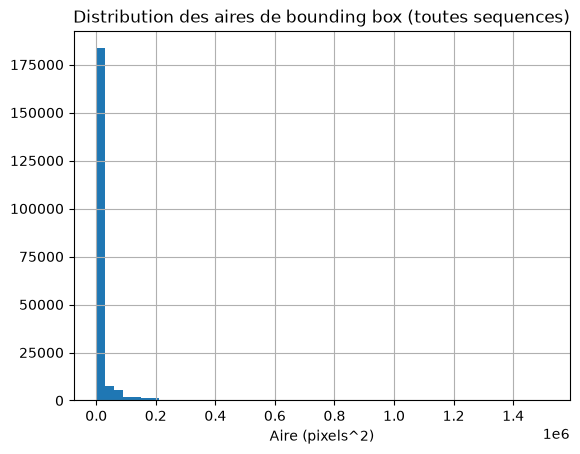

count    2.047010e+05
mean     1.938865e+04
std      5.348011e+04
min      2.210000e+02
25%      3.367000e+03
50%      7.600000e+03
75%      1.513600e+04
max      1.514253e+06
Name: area, dtype: float64
Part de tres petites boxes (aire < 1000 px^2) : 3.6%


In [36]:
df_all['area'] = df_all['bb_width'] * df_all['bb_height']
df_all['area'].hist(bins=50)
plt.title('Distribution des aires de bounding box (toutes sequences)')
plt.xlabel('Aire (pixels^2)')
plt.show()

print(df_all['area'].describe())
print(f"Part de tres petites boxes (aire < 1000 px^2) : {(df_all['area'] < 1000).mean():.1%}")

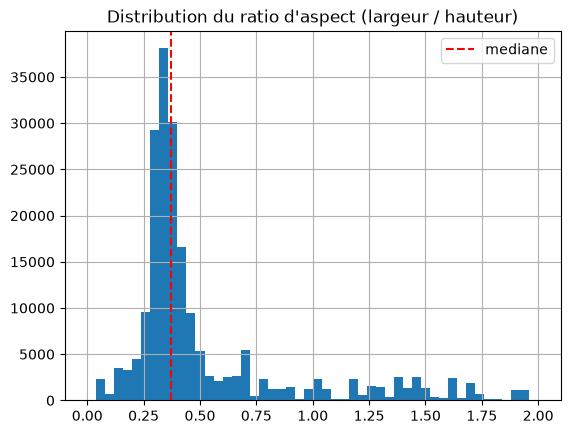

In [37]:
# Ratio d'aspect (largeur/hauteur) -- pour un pieton debout on attend un ratio << 1
df_all['aspect_ratio'] = df_all['bb_width'] / df_all['bb_height']
df_all['aspect_ratio'].hist(bins=50, range=(0, 2))
plt.title("Distribution du ratio d'aspect (largeur / hauteur)")
plt.axvline(df_all['aspect_ratio'].median(), color='red', linestyle='--', label='mediane')
plt.legend()
plt.show()

### Répartition des classes

MOT17 n'annote pas que des piétons : la colonne `class` distingue piétons, personnes statiques,
cyclistes, distracteurs, etc.

class
1     112297
2       1864
3       6189
4      13527
5       1050
6         11
7      12041
8       3595
9       3724
10     28573
11     19580
12      2250
Name: count, dtype: int64


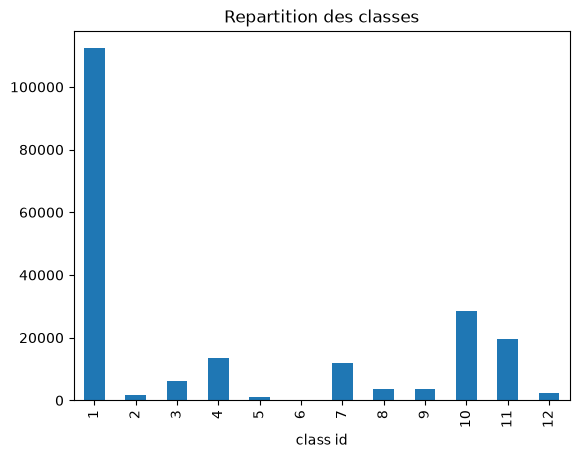


Part de la classe 1 (pieton) : 54.9%


In [38]:
class_counts = df_all['class'].value_counts().sort_index()
print(class_counts)
class_counts.plot(kind='bar', title='Repartition des classes')
plt.xlabel('class id')
plt.show()
print(f"\nPart de la classe 1 (pieton) : {(df_all['class'] == 1).mean():.1%}")

### Annotations à ignorer

`conf == 0` signale une annotation à exclure de l'évaluation officielle MOT (zone ambiguë,
distracteur...)

In [39]:
conf_counts = df_all['conf'].value_counts()
print(conf_counts)
print(f"Part des annotations avec conf=0 (a exclure) : {(df_all['conf'] == 0).mean():.1%}")

conf
1    112297
0     92404
Name: count, dtype: int64
Part des annotations avec conf=0 (a exclure) : 45.1%


### Bounding boxes partiellement hors-cadre

À détecter avant conversion au format YOLO : ces coordonnées doivent être clippées aux
dimensions de l'image

In [40]:
out_of_frame = df_all[(df_all.bb_left < 0) | (df_all.bb_top < 0)]
print(f'{len(out_of_frame)} / {len(df_all)} boxes avec coordonnee negative ({len(out_of_frame)/len(df_all):.2%})')

# Bornes vs resolution reelle de chaque sequence (jointure avec seqinfo)
res_map = {row['name']: (row['imWidth'], row['imHeight']) for _, row in seqinfo_df.iterrows()}
print('Resolutions disponibles :', set(res_map.values()))

18518 / 204701 boxes avec coordonnee negative (9.05%)
Resolutions disponibles : {(1920, 1080), (640, 480)}


### Distribution de la visibilité (occlusion)

`visibility` va de 0 (totalement occlus) à 1 (totalement visible). Une forte proportion de
faible visibilité = le tracker devra beaucoup s'appuyer sur le mouvement (Kalman) plutôt que sur
l'apparence, et la ré-ID devra gérer des crops partiellement occlus.

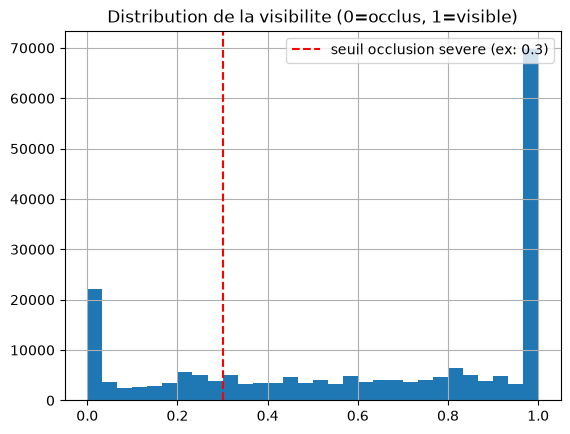

Part des annotations avec visibilite < 0.3 : 25.3%


In [41]:
df_all['visibility'].hist(bins=30)
plt.title('Distribution de la visibilite (0=occlus, 1=visible)')
plt.axvline(0.3, color='red', linestyle='--', label='seuil occlusion severe (ex: 0.3)')
plt.legend()
plt.show()

print(f"Part des annotations avec visibilite < 0.3 : {(df_all['visibility'] < 0.3).mean():.1%}")

### Longueur des trajectoires (nombre de frames par identité)

Une identité qui n'apparaît que 2-3 frames est peu utile pour évaluer la continuité du tracking ;
à l'inverse, de longues trajectoires avec des trous (frames manquantes) signalent des occlusions
prolongées — exactement le cas d'usage que la ré-ID doit couvrir.

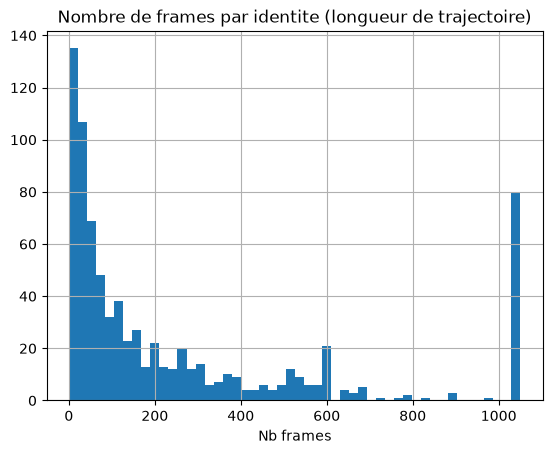

count     796.000000
mean      257.162060
std       321.927634
min         1.000000
25%        33.750000
50%       110.000000
75%       352.500000
max      1050.000000
Name: frame, dtype: float64


In [42]:
track_lengths = df_all.groupby(['sequence', 'id'])['frame'].nunique()
track_lengths.hist(bins=50)
plt.title("Nombre de frames par identite (longueur de trajectoire)")
plt.xlabel('Nb frames')
plt.show()
print(track_lengths.describe())

In [43]:
# Trous dans les trajectoires : une identite est-elle presente sur des frames non consecutives ?
def count_gaps(frames):
    frames = sorted(frames)
    return sum(1 for a, b in zip(frames, frames[1:]) if b - a > 1)

gaps = df_all.groupby(['sequence', 'id'])['frame'].apply(lambda s: count_gaps(s.tolist()))
print(f"Identites avec au moins une interruption (occlusion/sortie de champ) : {(gaps > 0).mean():.1%}")
print(f"Nombre moyen d'interruptions par identite (parmi celles qui en ont) : {gaps[gaps > 0].mean():.2f}")

Identites avec au moins une interruption (occlusion/sortie de champ) : 0.0%
Nombre moyen d'interruptions par identite (parmi celles qui en ont) : nan


## 4. Visualisation de frames annotées

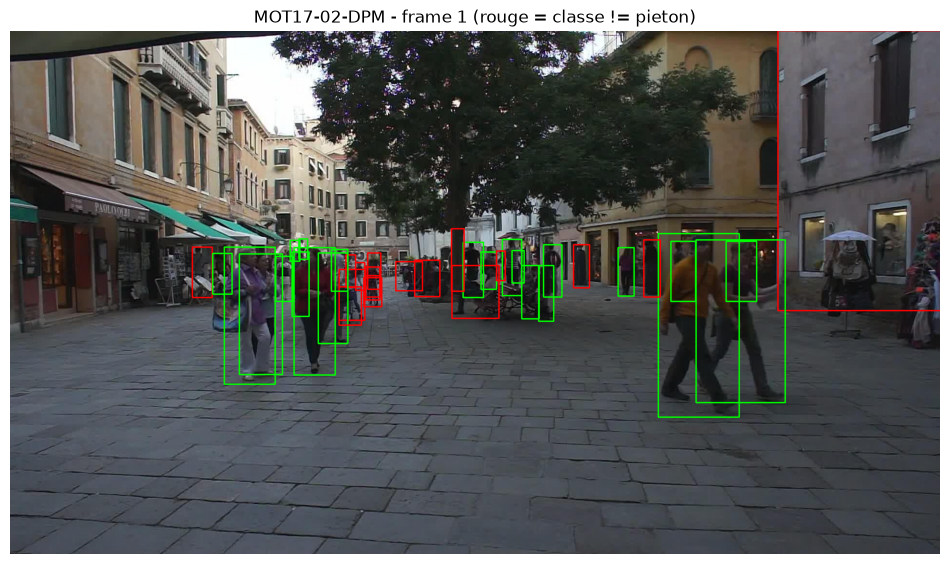

In [44]:
def draw_boxes(frame_path, boxes):
    img = cv2.imread(str(frame_path))
    for _, row in boxes.iterrows():
        x, y, w, h = int(row.bb_left), int(row.bb_top), int(row.bb_width), int(row.bb_height)
        color = (0, 255, 0) if row['class'] == 1 else (0, 0, 255)  # rouge = non-pieton
        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

seq0 = sequences[0]
frame_1_boxes = df_all[(df_all.sequence == base_names[0]) & (df_all.frame == 1)]
plt.figure(figsize=(12, 8))
plt.imshow(draw_boxes(seq0 / 'img1' / '000001.jpg', frame_1_boxes))
plt.title(f'{seq0.name} - frame 1 (rouge = classe != pieton)')
plt.axis('off')
plt.show()

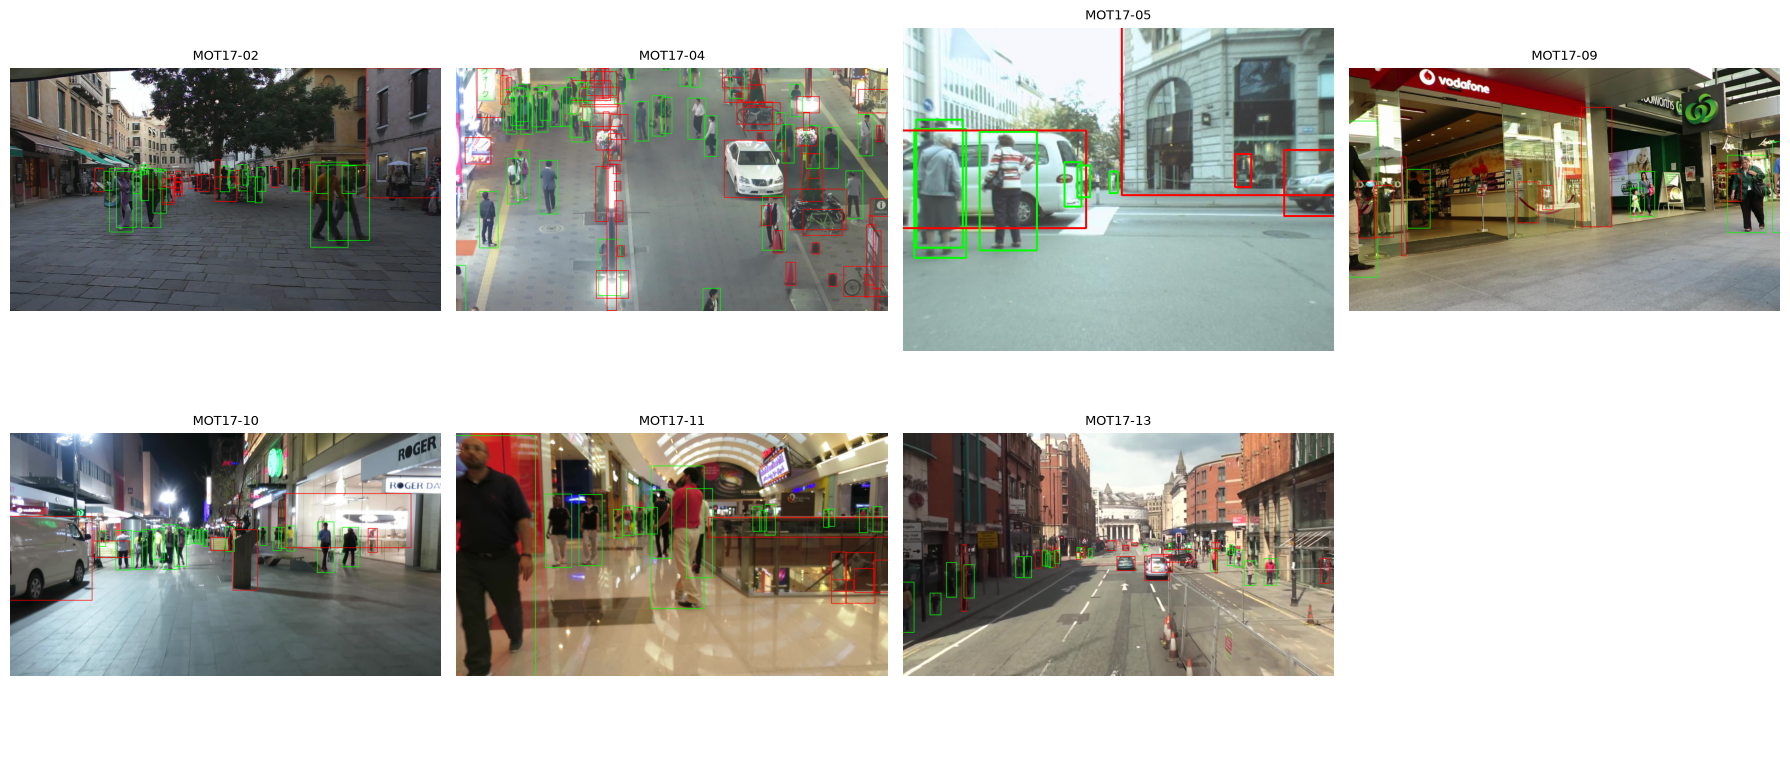

In [45]:
# Une grille avec une frame de chaque sequence, pour comparer densite/eclairage/angle de vue
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, b in zip(axes.flat, base_names):
    seq_path = next(s for s in sequences if s.name.startswith(b + '-'))
    boxes = df_all[(df_all.sequence == b) & (df_all.frame == 1)]
    ax.imshow(draw_boxes(seq_path / 'img1' / '000001.jpg', boxes))
    ax.set_title(b, fontsize=9)
    ax.axis('off')
for ax in axes.flat[len(base_names):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Market-1501 — aperçu ré-identification

Rappel de la structure réelle de l'archive (voir `configs/datasets.yaml`) :
- `bounding_box_train` : 12936 images, 751 identités -> entraînement de l'encoder
- `bounding_box_test` : 19732 images -> galerie de recherche pour l'évaluation
- `query` : 3368 images -> requêtes à retrouver dans `bounding_box_test`
- `gt_bbox` / `gt_query` : vérité terrain pour l'évaluation (good/junk/distractors)

Convention de nommage des fichiers : `0001_c1s1_000151_00.jpg` = identité 0001, caméra 1, séquence 1.
On ne touche pas à `bounding_box_test`/`query`/`gt_*` pour l'instant : réservé à l'évaluation en
semaine 5, pas à l'entraînement.

12936 images trouvees dans bounding_box_train


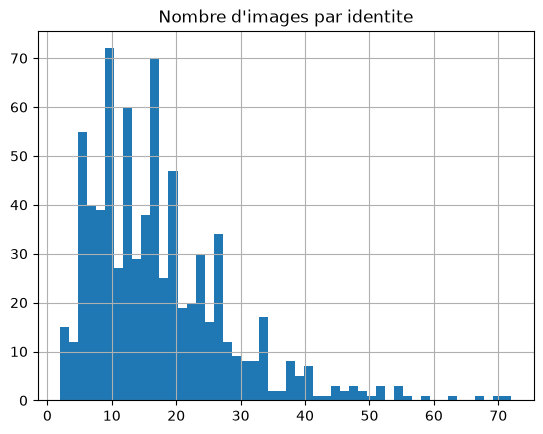

count    751.000000
mean      17.225033
std       10.773484
min        2.000000
25%        9.000000
50%       15.000000
75%       22.000000
max       72.000000
Name: count, dtype: float64


In [46]:
market_images = sorted((MARKET1501_DIR / 'bounding_box_train').glob('*.jpg'))
print(f'{len(market_images)} images trouvees dans bounding_box_train')

ids = [f.stem.split('_')[0] for f in market_images]
cams = [re.search(r'_c(\d)s', f.name).group(1) for f in market_images]

id_counts = pd.Series(ids).value_counts()
id_counts.hist(bins=50)
plt.title("Nombre d'images par identite")
plt.show()
print(id_counts.describe())

### Identités junk/distracteurs

Par convention Market-1501, l'identité **`0000`** correspond à des détections « junk »
(faux positifs de détecteur de personnes) et **`-1`** à des distracteurs. Ces images ne doivent
**pas** être utilisées comme vraies identités

In [47]:
junk_mask = pd.Series(ids).isin(['0000', '-1'])
print(f"Images junk/distracteurs dans bounding_box_train : {junk_mask.sum()} ({junk_mask.mean():.2%})")
print(f"Identites reelles utilisables pour l'entrainement : {pd.Series(ids)[~junk_mask].nunique()}")

Images junk/distracteurs dans bounding_box_train : 0 (0.00%)
Identites reelles utilisables pour l'entrainement : 751


### Nombre de caméras distinctes par identité

Vérifier qu'on a bien des vues variées par identité (nécessaire pour que le triplet
loss apprenne une invariance au point de vue, pas juste à reconnaître des quasi-doublons).

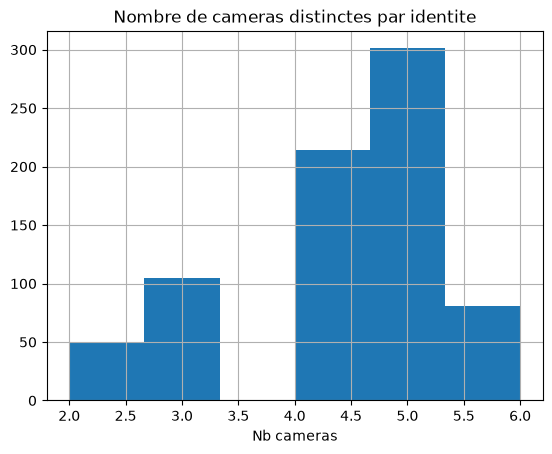

Identites vues par une seule camera (moins utiles pour le triplet loss) : 0.0%


In [48]:
cam_per_id = pd.DataFrame({'id': ids, 'cam': cams})
cam_per_id = cam_per_id[~cam_per_id.id.isin(['0000', '-1'])]
n_cams_per_id = cam_per_id.groupby('id')['cam'].nunique()

n_cams_per_id.hist(bins=6)
plt.title('Nombre de cameras distinctes par identite')
plt.xlabel('Nb cameras')
plt.show()
print(f"Identites vues par une seule camera (moins utiles pour le triplet loss) : {(n_cams_per_id == 1).mean():.1%}")

### Cohérence des dimensions d'image

Les crops Market-1501 sont normalement tous en 128×64 (h×w) — à vérifier, car une taille
incohérente casserait un batch d'entraînement sans padding/resize explicite.

In [49]:
sample = np.random.RandomState(0).choice(market_images, size=200, replace=False)
shapes = [cv2.imread(str(p)).shape[:2] for p in sample]
shape_counts = pd.Series(shapes).value_counts()
print(shape_counts)

(128, 64)    200
Name: count, dtype: int64


### Aperçu visuel : une identité vue par plusieurs caméras

Bon test de sanité avant d'entraîner : les crops doivent bien représenter la même personne,
même si l'éclairage/angle change.

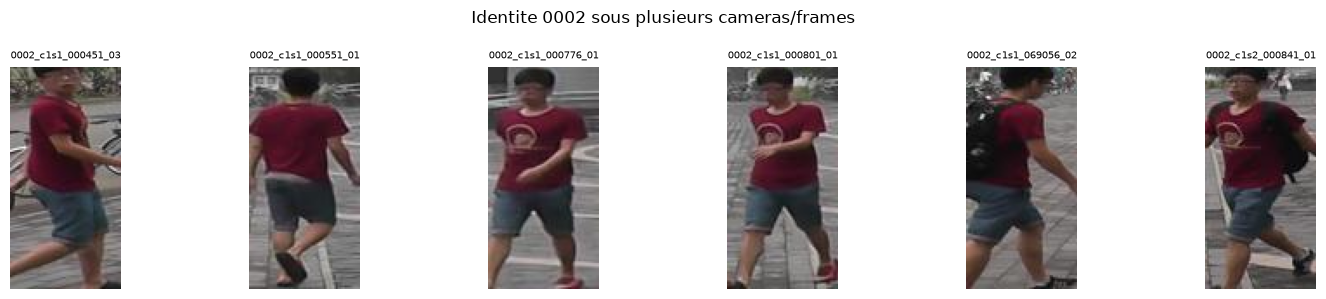

In [50]:
sample_id = n_cams_per_id[n_cams_per_id >= 3].index[0]
sample_imgs = [f for f in market_images if f.stem.split('_')[0] == sample_id][:6]

fig, axes = plt.subplots(1, len(sample_imgs), figsize=(15, 3))
for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.stem, fontsize=7)
    ax.axis('off')
plt.suptitle(f'Identite {sample_id} sous plusieurs cameras/frames')
plt.tight_layout()
plt.show()

## Conclusions et points d'attention pour la suite

**MOT17**
- 21 dossiers de séquences mais seulement 7 vidéos uniques (DPM/FRCNN/SDP partagent le même
  `gt.txt`) → le split train/val devra se faire par vidéo de base, jamais par variante.
- Toutes les classes ne sont pas des piétons → filtrer `class == 1` (et `conf == 1`) lors de la
  conversion au format YOLO.
- Des bounding boxes sortent du cadre → clipper aux dimensions de l'image avant export YOLO.
- Une part significative d'identités a des interruptions (occlusions) → confirme l'intérêt du
  module de ré-ID, ce n'est pas un cas marginal.

**Market-1501**
- Les identités `0000` et `-1` sont des junk/distracteurs, pas de vraies identités → à exclure
  du triplet loss.
- La plupart des identités sont vues par plusieurs caméras → bon signal pour apprendre une
  représentation invariante au point de vue.
- Images en 128×64 (h×w) de façon homogène → pas de retraitement de taille nécessaire côté
  Market-1501 (mais il faudra probablement resize les crops MOT17 vers ce même format au moment
  de connecter détection/tracking et ré-ID).

**Points d'attention**
- Règle de split MOT17 par vidéo de base
- Règle de filtrage (`class`, `conf`, clipping des coordonnées) pour la conversion YOLO
- Exclusion des identités junk Market-1501
- Seuil de visibilité choisi pour distinguer "occlusion sévère" si utilisé plus tard dans le
  tracker